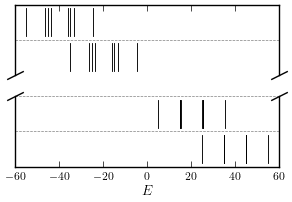

In [1]:
import matplotlib.pyplot as plt  # plotting library
import numpy as np  # general math functions 

plt.style.use('aps.mplstyle')

# Load energy levels
data = np.load('data/el.npz', allow_pickle=True)
level_list = data['level_list']
p_values = data['p_values']

# Select only the first two and last two p values
selected_p_values = p_values[:2].tolist() + p_values[-2:].tolist()

# Plot the energy spectrum with a broken y-axis
plt.style.use('aps.mplstyle')
# Create two subplots with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0.30)  # Adjust space between axes

# Plot the energy levels on both subplots
for i, p in enumerate(selected_p_values):
    levels = level_list[p]
    for level in levels:
        ax1.plot([level, level], [i - 0.4, i + 0.4], color='black', linewidth=0.5)
        ax2.plot([level, level], [i - 0.4, i + 0.4], color='black', linewidth=0.5)
    # divide the different p values
    ax1.plot([-60, 60], [i - 0.5, i - 0.5], color='gray', linestyle='--', linewidth=0.5)
    ax2.plot([-60, 60], [i - 0.5, i - 0.5], color='gray', linestyle='--', linewidth=0.5)

# Set y-axis limits to create the broken effect
ax1.set_ylim(1.5, 3.5)  # Top part
ax2.set_ylim(-0.5, 1.5)  # Bottom part

# Hide the spines between the axes
ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Hide the top tick labels
ax2.xaxis.set_ticks_position('bottom')

# Add diagonal lines to indicate the break
d = 0.5  # Proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)
ax1.set_xlim(-60,60)
ax2.set_xlim(-60,60)
ax1.set_yticks([])
ax2.set_yticks([])
ax2.set_xlabel(r'$E$')
plt.savefig('figures/energy_levels.pdf', dpi=300, bbox_inches='tight')
plt.show()